In [80]:
import pandas as pd
from sklearn.model_selection import train_test_split

file_path = '/Users/melina/Downloads/finalpaperdataset.csv'
df = pd.read_csv(file_path)

X = df.drop(columns='Decision')
y = df['Decision']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, 
    test_size=0.30,      
    random_state=42, 
    stratify=y          
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, 
    test_size=0.50,       
    random_state=42, 
    stratify=y_temp
)


print(f"Train set shape: {X_train.shape}, Validation set shape: {X_val.shape}, Test set shape: {X_test.shape}")
print(f"Train target distribution:\n{y_train.value_counts(normalize=True)}")
print(f"Validation target distribution:\n{y_val.value_counts(normalize=True)}")
print(f"Test target distribution:\n{y_test.value_counts(normalize=True)}")


Train set shape: (9100, 15), Validation set shape: (1950, 15), Test set shape: (1950, 15)
Train target distribution:
Decision
1    0.536264
0    0.463736
Name: proportion, dtype: float64
Validation target distribution:
Decision
1    0.53641
0    0.46359
Name: proportion, dtype: float64
Test target distribution:
Decision
1    0.53641
0    0.46359
Name: proportion, dtype: float64


In [81]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix
import numpy as np
import pandas as pd

X_train_val = np.vstack((X_train, X_val))
y_train_val = np.hstack((y_train, y_val))

xgb_final = XGBClassifier(
    colsample_bytree=0.7,
    learning_rate=0.1,
    max_depth=8,
    n_estimators=100,
    subsample=1.0,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

xgb_final.fit(X_train_val, y_train_val)

y_test_pred = xgb_final.predict(X_test)
y_test_proba = xgb_final.predict_proba(X_test)[:, 1]

test_accuracy = accuracy_score(y_test, y_test_pred)
test_roc_auc = roc_auc_score(y_test, y_test_proba)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test ROC-AUC: {test_roc_auc:.4f}\n")

print("Classification Report:")
print(classification_report(y_test, y_test_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))

/opt/anaconda3/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [05:34:52] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Test Accuracy: 0.7256
Test ROC-AUC: 0.7944

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.72      0.71       904
           1       0.75      0.73      0.74      1046

    accuracy                           0.73      1950
   macro avg       0.72      0.73      0.72      1950
weighted avg       0.73      0.73      0.73      1950

Confusion Matrix:
[[651 253]
 [282 764]]


Erorr analysis

In [82]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix


feature_cols = [col for col in df.columns if col != 'Decision']

test_df = pd.DataFrame(X_test, columns=feature_cols)
test_df['true_label'] = y_test
test_df['pred_label'] = y_test_pred
test_df['pred_prob'] = y_test_proba

false_pos = test_df[(test_df['true_label'] == 0) & (test_df['pred_label'] == 1)]

false_neg = test_df[(test_df['true_label'] == 1) & (test_df['pred_label'] == 0)]

print("\n=== MISCLASSIFIED SAMPLES (TEST SET) ===")

print("\n--- False Positives (Predicted 1, True 0) ---")
print(false_pos.head(20))

print("\n--- False Negatives (Predicted 0, True 1) ---")
print(false_neg.head(20))

print("\nCounts:")
print("False Positives:", len(false_pos))
print("False Negatives:", len(false_neg))



=== MISCLASSIFIED SAMPLES (TEST SET) ===

--- False Positives (Predicted 1, True 0) ---
       Applicant_GPA  Decision_Year  Target_University_FSR_Score  \
9895        0.210326      -1.280556                    -0.664413   
7176        0.561596      -0.631313                    -0.154650   
5101        0.825048       0.017929                    -0.004889   
8586       -1.985110      -1.280556                    -1.436257   
6522       -0.887392      -0.631313                     1.221998   
11949       0.210326      -1.280556                    -0.183450   
251        -1.809475       1.316414                     0.778476   
10130       0.737231      -1.280556                    -1.200096   
4315        1.088501       0.667171                    -1.476577   
11102       0.210326       1.316414                    -0.382171   
7718       -0.623940      -0.631313                     1.175918   
6176       -3.302371      -0.631313                     1.175918   
9050        0.649413      -

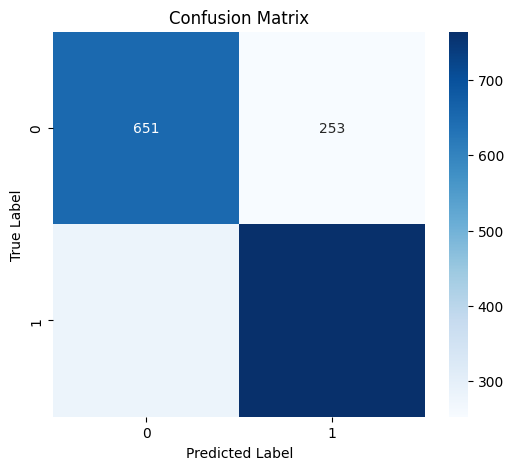

Top misclassified pairs (true -> predicted): [(1, 0, 282), (0, 1, 253)]


In [83]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import pandas as pd

cm = confusion_matrix(y_test, y_test_pred)
cm_df = pd.DataFrame(cm, index=xgb_final.classes_, columns=xgb_final.classes_)

plt.figure(figsize=(6,5))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()

misclassified_pairs = []
for i, true_label in enumerate(xgb_final.classes_):
    for j, pred_label in enumerate(xgb_final.classes_):
        if i != j and cm[i, j] > 0:
            misclassified_pairs.append((true_label, pred_label, cm[i,j]))
print("Top misclassified pairs (true -> predicted):", sorted(misclassified_pairs, key=lambda x: x[2], reverse=True))


In [84]:
import numpy as np
import pandas as pd

feature_cols = [col for col in df.columns if col != 'Decision']

confidence_scores = np.max(xgb_final.predict_proba(X_test), axis=1)

low_confidence_idx = np.where(confidence_scores < 0.6)[0]
print(f"Number of low-confidence predictions (<0.6): {len(low_confidence_idx)}")

low_confidence_samples = X_test.iloc[low_confidence_idx].copy()

low_confidence_samples['True_Label'] = y_test.iloc[low_confidence_idx].values
low_confidence_samples['Pred_Label'] = y_test_pred[low_confidence_idx]
low_confidence_samples['Confidence'] = confidence_scores[low_confidence_idx]

low_confidence_samples.head()


Number of low-confidence predictions (<0.6): 360


,Applicant_GPA,Decision_Year,Target_University_FSR_Score,Target_University_CPF_Score,Target_University_ISR_Score,Target_University_QS_Rank,Target_Degree_Type,Applicant_Status,Target_University_Status,Target_Program,Target_Program_Discipline,Target_University,Target_Country,Program_Admission_Rate,Program_x_QS_Rank,True_Label,Pred_Label,Confidence
2239,0.825048,1.316414,-0.105690,-0.905712,-1.277134,2.519306,2,1.0,1.0,0.083308,0.087077,0.010154,0.845308,0.541090,0.209878,1,0,0.503187
2762,1.088501,1.316414,0.501994,0.687028,1.226908,-0.459465,2,2.0,2.0,0.082231,0.139077,0.006846,0.845308,0.670720,-0.037782,1,0,0.569952
1949,0.649413,1.316414,-1.505377,1.124755,0.335801,-0.362347,2,1.0,1.0,0.026769,0.026769,0.004077,0.054462,0.353448,-0.009700,0,0,0.529009
8586,-1.985110,-1.280556,-1.436257,-0.122216,0.891545,0.114135,1,1.0,1.0,0.019538,0.030462,0.003154,0.054462,0.539370,0.002230,0,1,0.570326
11007,0.210326,-1.280556,-0.338971,0.216195,1.268429,-0.732607,2,1.0,1.0,0.083308,0.087077,0.014308,0.054462,0.541090,-0.061032,1,1,0.508371


In [85]:

misclassified_idx = np.where(y_test != y_test_pred)[0]

misclassified_samples = X_test.iloc[misclassified_idx].copy()

misclassified_samples['True_Label'] = y_test.iloc[misclassified_idx].values
misclassified_samples['Pred_Label'] = y_test_pred[misclassified_idx]
misclassified_samples['Confidence'] = confidence_scores[misclassified_idx]

low_conf_misclassified = misclassified_samples[misclassified_samples['Confidence'] < 0.6]
low_conf_misclassified.head()


,Applicant_GPA,Decision_Year,Target_University_FSR_Score,Target_University_CPF_Score,Target_University_ISR_Score,Target_University_QS_Rank,Target_Degree_Type,Applicant_Status,Target_University_Status,Target_Program,Target_Program_Discipline,Target_University,Target_Country,Program_Admission_Rate,Program_x_QS_Rank,True_Label,Pred_Label,Confidence
2239,0.825048,1.316414,-0.105690,-0.905712,-1.277134,2.519306,2,1.0,1.0,0.083308,0.087077,0.010154,0.845308,0.541090,0.209878,1,0,0.503187
2762,1.088501,1.316414,0.501994,0.687028,1.226908,-0.459465,2,2.0,2.0,0.082231,0.139077,0.006846,0.845308,0.670720,-0.037782,1,0,0.569952
8586,-1.985110,-1.280556,-1.436257,-0.122216,0.891545,0.114135,1,1.0,1.0,0.019538,0.030462,0.003154,0.054462,0.539370,0.002230,0,1,0.570326
655,1.088501,1.316414,-0.088409,0.639209,-0.357282,-0.620315,2,2.0,1.0,0.017154,0.017154,0.007231,0.845308,0.430493,-0.010641,1,0,0.576487
11949,0.210326,-1.280556,-0.183450,1.312353,1.293980,-0.662804,2,1.0,2.0,0.083308,0.087077,0.018385,0.845308,0.541090,-0.055217,0,1,0.515694


Total TEST samples: 1950
Misclassified samples: 535
High-confidence errors (>0.84 prob): 41
Low-confidence errors (<0.42 prob): 218
Low-confidence correct predictions: 574


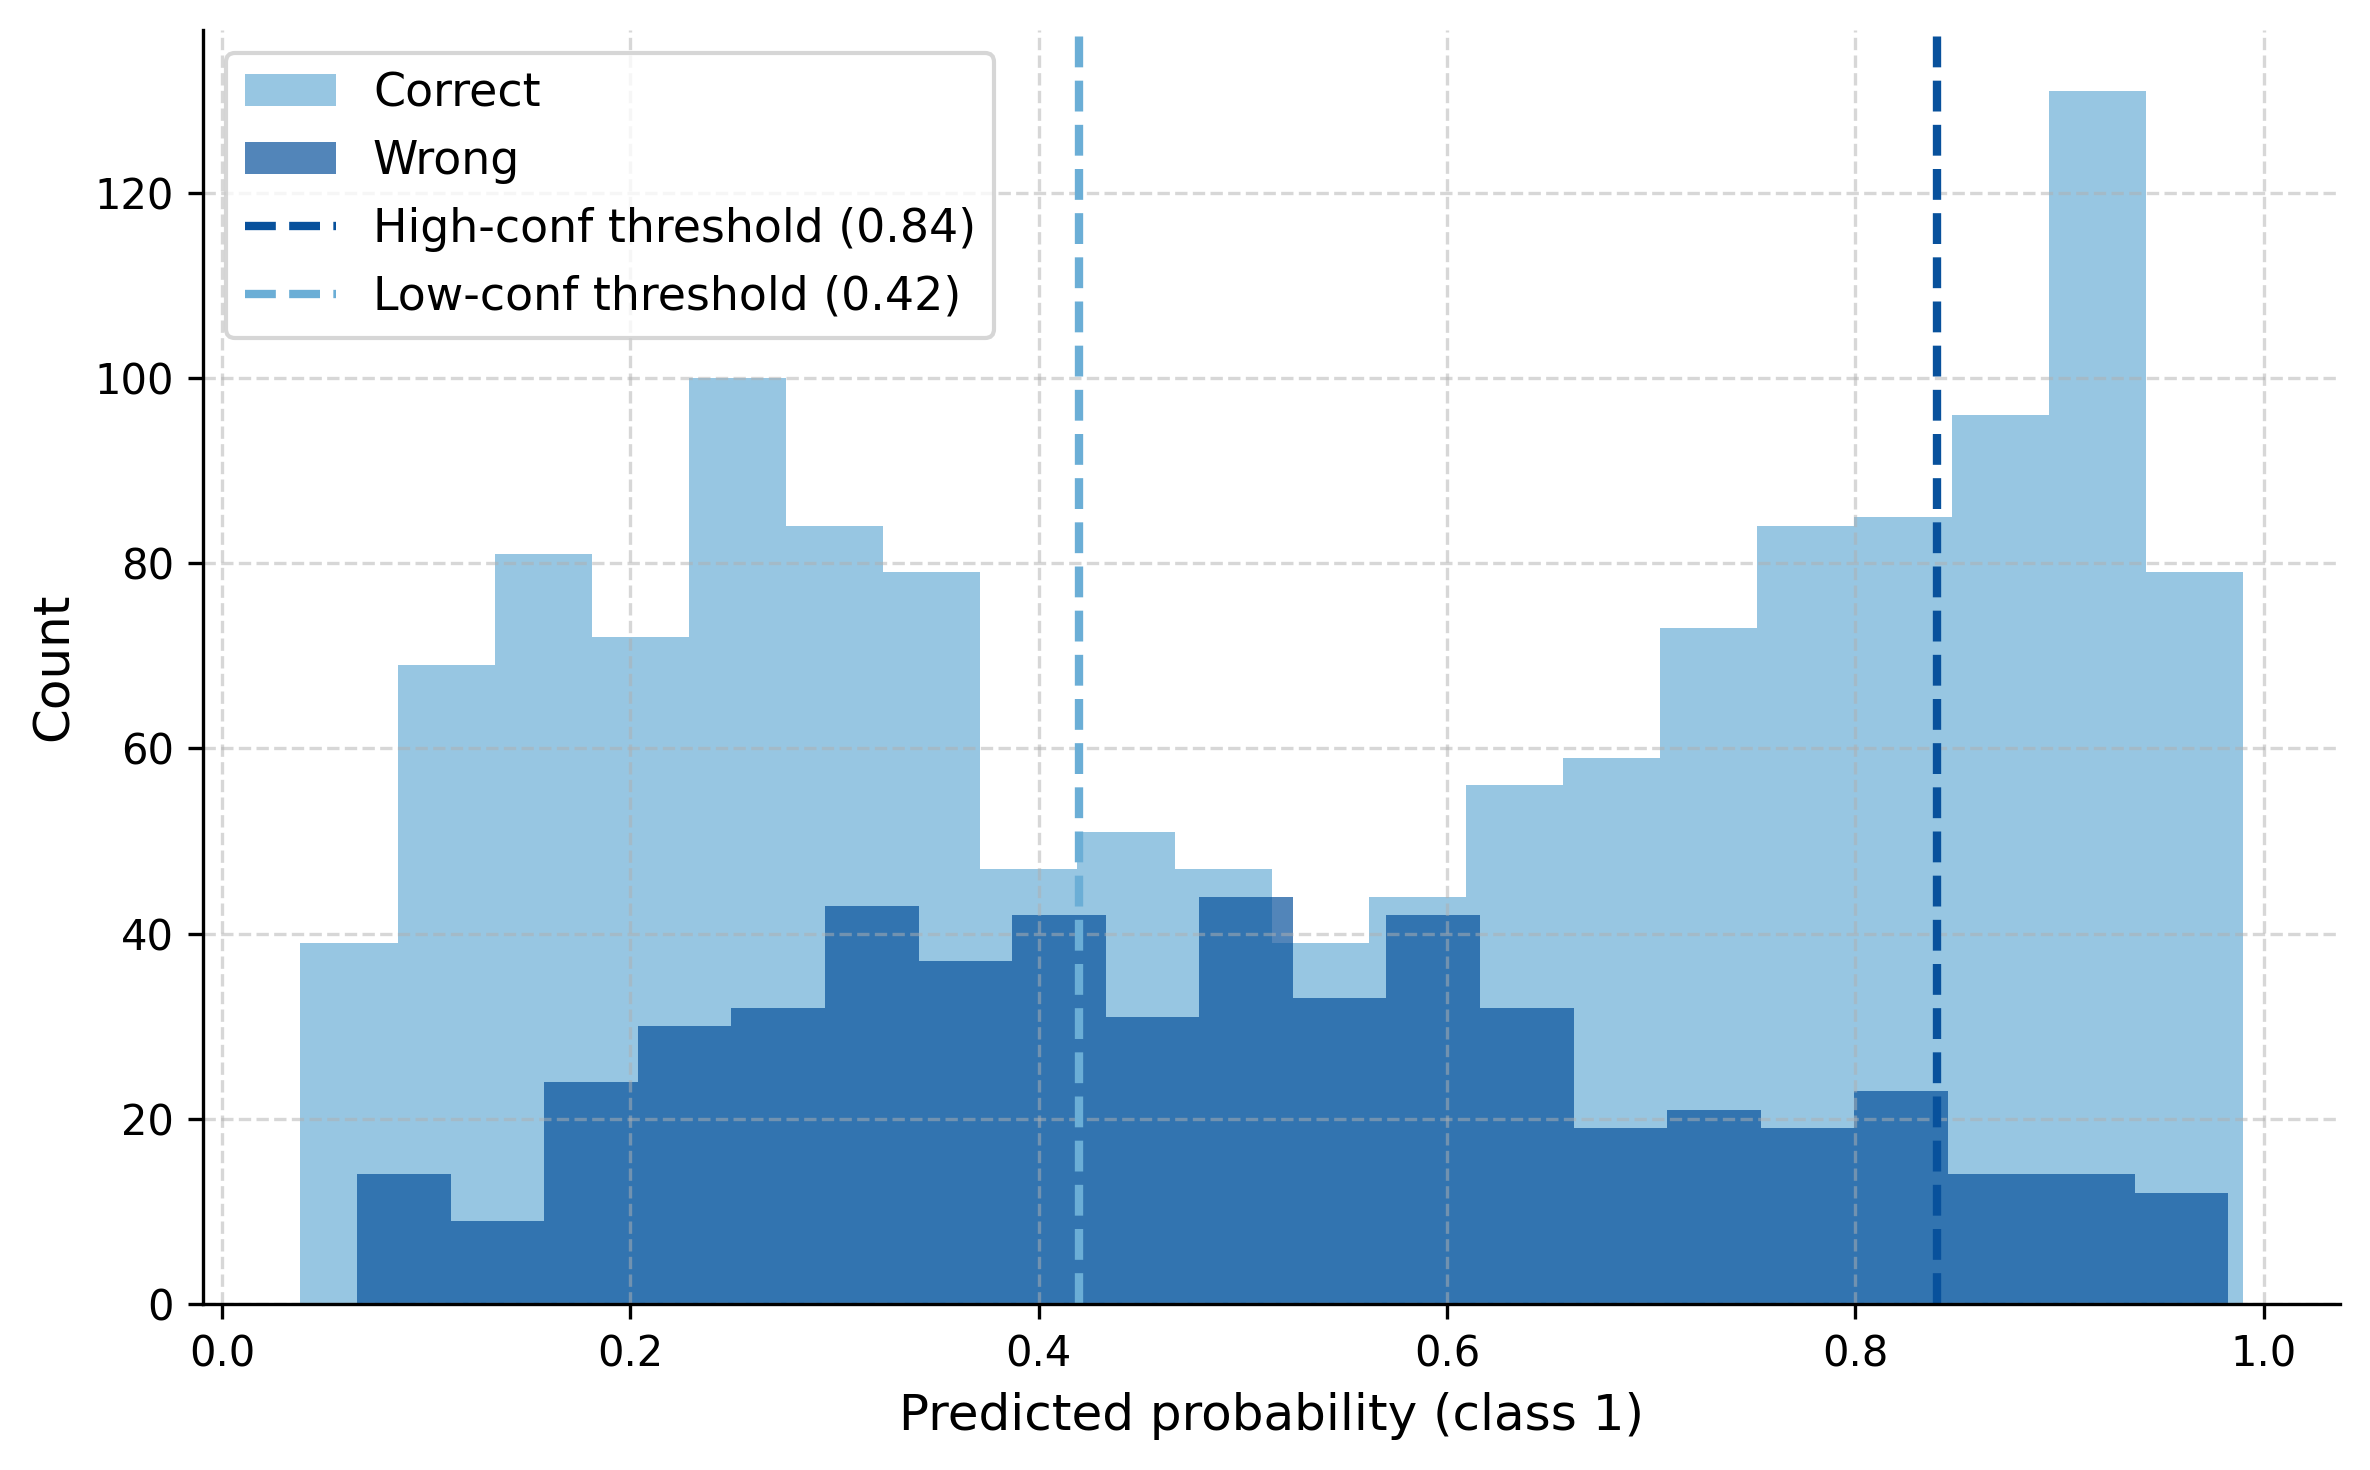

In [86]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

y_pred = xgb_final.predict(X_test)
y_prob = xgb_final.predict_proba(X_test)[:, 1]

wrong_mask = (y_test != y_pred)
correct_mask = ~wrong_mask

high_conf_threshold = 0.84
low_conf_threshold = 0.42

high_conf_wrong_idx = np.where(wrong_mask & (y_prob > high_conf_threshold))[0]
low_conf_wrong_idx = np.where(wrong_mask & (y_prob < low_conf_threshold))[0]
low_conf_correct_idx = np.where(correct_mask & (y_prob < low_conf_threshold))[0]

print("Total TEST samples:", len(y_test))
print("Misclassified samples:", wrong_mask.sum())
print("High-confidence errors (>0.84 prob):", len(high_conf_wrong_idx))
print("Low-confidence errors (<0.42 prob):", len(low_conf_wrong_idx))
print("Low-confidence correct predictions:", len(low_conf_correct_idx))

fig, ax = plt.subplots(figsize=(8, 5), dpi=300)

light_blue = '#6baed6'  
deep_blue = '#08519c'   


ax.hist(y_prob[correct_mask], bins=20, alpha=0.7, color=light_blue, label='Correct')
ax.hist(y_prob[wrong_mask], bins=20, alpha=0.7, color=deep_blue, label='Wrong')

ax.axvline(x=high_conf_threshold, color=deep_blue, linestyle='--', linewidth=2,
           label=f'High-conf threshold ({high_conf_threshold})')
ax.axvline(x=low_conf_threshold, color=light_blue, linestyle='--', linewidth=2,
           label=f'Low-conf threshold ({low_conf_threshold})')

ax.set_xlabel('Predicted probability (class 1)', fontsize=12, weight='medium')
ax.set_ylabel('Count', fontsize=12, weight='medium')

ax.legend(fontsize=11)

ax.grid(True, linestyle='--', alpha=0.5)
import seaborn as sns; sns.despine(ax=ax, top=True, right=True)

plt.tight_layout()

plt.savefig("pred_prob_hist_academic_blue.pdf", format='pdf', bbox_inches='tight')

plt.show()


In [87]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report

y_pred_xgb = xgb_final.predict(X_train)
y_prob_xgb = xgb_final.predict_proba(X_train)[:, 1]

misclassified_idx = np.where(y_pred_xgb != y_train)[0]
borderline_idx = np.where((y_prob_xgb > 0.4) & (y_prob_xgb < 0.6))[0]

residual_idx = np.unique(np.concatenate([misclassified_idx, borderline_idx]))

X_residual = X_train.iloc[residual_idx].copy()
y_residual = y_train.iloc[residual_idx].copy()

X_residual['xgb_prob'] = y_prob_xgb[residual_idx]


param_grid = {
    'weights': ['uniform', 'distance'],
    'p': [1, 2]  
}

knn_grid = GridSearchCV(
    KNeighborsClassifier(n_neighbors=9),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
knn_grid.fit(X_residual, y_residual)

print("Best kNN parameters:", knn_grid.best_params_)

knn_best = knn_grid.best_estimator_

y_hybrid = y_pred_xgb.copy()

X_residual_full = X_train.iloc[residual_idx].copy()
X_residual_full['xgb_prob'] = y_prob_xgb[residual_idx]

y_hybrid[residual_idx] = knn_best.predict(X_residual_full)

print("XGBoost Accuracy (train):", accuracy_score(y_train, y_pred_xgb))
print("Hybrid Accuracy (train):", accuracy_score(y_train, y_hybrid))
print("\nClassification Report for Hybrid Model (train):\n")
print(classification_report(y_train, y_hybrid, target_names=['Rejected', 'Accepted']))


Best kNN parameters: {'p': 1, 'weights': 'uniform'}
XGBoost Accuracy (train): 0.8804395604395604
Hybrid Accuracy (train): 0.9487912087912088

Classification Report for Hybrid Model (train):

              precision    recall  f1-score   support

    Rejected       0.95      0.94      0.94      4220
    Accepted       0.95      0.96      0.95      4880

    accuracy                           0.95      9100
   macro avg       0.95      0.95      0.95      9100
weighted avg       0.95      0.95      0.95      9100



In [88]:

y_pred_xgb_test = xgb_final.predict(X_test)
y_prob_xgb_test = xgb_final.predict_proba(X_test)[:, 1]

misclassified_idx_test = np.where(y_pred_xgb_test != y_test)[0]
borderline_idx_test = np.where((y_prob_xgb_test > 0.4) & (y_prob_xgb_test < 0.6))[0]

residual_idx_test = np.unique(np.concatenate([misclassified_idx_test, borderline_idx_test]))

X_residual_test = X_test.iloc[residual_idx_test].copy()
X_residual_test['xgb_prob'] = y_prob_xgb_test[residual_idx_test]


y_hybrid_test = y_pred_xgb_test.copy()

y_hybrid_test[residual_idx_test] = knn_best.predict(X_residual_test)

print("XGBoost Accuracy (test):", accuracy_score(y_test, y_pred_xgb_test))
print("Hybrid Accuracy (test):", accuracy_score(y_test, y_hybrid_test))
print("\nClassification Report for Hybrid Model (test):\n")
print(classification_report(y_test, y_hybrid_test, target_names=['Rejected', 'Accepted']))


XGBoost Accuracy (test): 0.7256410256410256
Hybrid Accuracy (test): 0.8723076923076923

Classification Report for Hybrid Model (test):

              precision    recall  f1-score   support

    Rejected       0.88      0.84      0.86       904
    Accepted       0.87      0.90      0.88      1046

    accuracy                           0.87      1950
   macro avg       0.87      0.87      0.87      1950
weighted avg       0.87      0.87      0.87      1950



xgboost with svm 

In [89]:
import numpy as np
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report

y_pred_xgb = xgb_final.predict(X_train)
y_prob_xgb = xgb_final.predict_proba(X_train)[:, 1]

misclassified_idx = np.where(y_pred_xgb != y_train)[0]
borderline_idx = np.where((y_prob_xgb > 0.4) & (y_prob_xgb < 0.6))[0]

residual_idx = np.unique(np.concatenate([misclassified_idx, borderline_idx]))

X_residual = X_train.iloc[residual_idx].copy()
y_residual = y_train.iloc[residual_idx].copy()

X_residual['xgb_prob'] = y_prob_xgb[residual_idx]

param_grid = {
    'C': [0.1, 1, 10, 50],
    'gamma': ['scale', 'auto', 0.01, 0.1, 1]
}

svm_grid = GridSearchCV(
    SVC(kernel='rbf', probability=True),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
svm_grid.fit(X_residual, y_residual)

print("Best SVM parameters:", svm_grid.best_params_)

svm_best = svm_grid.best_estimator_

y_hybrid = y_pred_xgb.copy()

X_residual_full = X_train.iloc[residual_idx].copy()
X_residual_full['xgb_prob'] = y_prob_xgb[residual_idx]

y_hybrid[residual_idx] = svm_best.predict(X_residual_full)

print("XGBoost Accuracy (train):", accuracy_score(y_train, y_pred_xgb))
print("Hybrid Accuracy (train):", accuracy_score(y_train, y_hybrid))
print("\nClassification Report for Hybrid Model (train):\n")
print(classification_report(y_train, y_hybrid, target_names=['Rejected', 'Accepted']))


Best SVM parameters: {'C': 50, 'gamma': 0.01}
XGBoost Accuracy (train): 0.8804395604395604
Hybrid Accuracy (train): 0.9495604395604396

Classification Report for Hybrid Model (train):

              precision    recall  f1-score   support

    Rejected       0.95      0.94      0.95      4220
    Accepted       0.95      0.96      0.95      4880

    accuracy                           0.95      9100
   macro avg       0.95      0.95      0.95      9100
weighted avg       0.95      0.95      0.95      9100



In [90]:

y_pred_xgb_test = xgb_final.predict(X_test)
y_prob_xgb_test = xgb_final.predict_proba(X_test)[:, 1]


misclassified_idx_test = np.where(y_pred_xgb_test != y_test)[0]
borderline_idx_test = np.where((y_prob_xgb_test > 0.4) & (y_prob_xgb_test < 0.6))[0]

residual_idx_test = np.unique(np.concatenate([misclassified_idx_test, borderline_idx_test]))

X_residual_test = X_test.iloc[residual_idx_test].copy()
X_residual_test['xgb_prob'] = y_prob_xgb_test[residual_idx_test]

y_hybrid_test = y_pred_xgb_test.copy()

y_hybrid_test[residual_idx_test] = svm_best.predict(X_residual_test)

print("XGBoost Accuracy (test):", accuracy_score(y_test, y_pred_xgb_test))
print("Hybrid Accuracy (test):", accuracy_score(y_test, y_hybrid_test))
print("\nClassification Report for Hybrid Model (test):\n")
print(classification_report(y_test, y_hybrid_test, target_names=['Rejected', 'Accepted']))


XGBoost Accuracy (test): 0.7256410256410256
Hybrid Accuracy (test): 0.8738461538461538

Classification Report for Hybrid Model (test):

              precision    recall  f1-score   support

    Rejected       0.87      0.85      0.86       904
    Accepted       0.87      0.89      0.88      1046

    accuracy                           0.87      1950
   macro avg       0.87      0.87      0.87      1950
weighted avg       0.87      0.87      0.87      1950



regularization on xgboost

In [91]:

from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

param_grid_reg = {
    'reg_alpha': [0, 0.01, 0.1],
    'reg_lambda': [1, 1.5, 2],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0]
}

xgb_reg_grid = GridSearchCV(
    XGBClassifier(
        n_estimators=xgb_final.n_estimators,
        max_depth=xgb_final.max_depth,
        learning_rate=xgb_final.learning_rate,
        random_state=42
    ),
    param_grid=param_grid_reg,
    scoring='accuracy',
    cv=5,
    n_jobs=-1
)
xgb_reg_grid.fit(X_train, y_train)

xgb_best_reg = xgb_reg_grid.best_estimator_
print("Best fine-grained regularization:", xgb_reg_grid.best_params_)


Best fine-grained regularization: {'colsample_bytree': 0.8, 'reg_alpha': 0.1, 'reg_lambda': 1, 'subsample': 0.8}


choosing the proper k for knn

In [92]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11, 13],
    'weights': ['uniform', 'distance']  
}

knn_grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_knn,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
knn_grid.fit(X_residual, y_residual)

knn_best = knn_grid.best_estimator_
print("Best kNN params:", knn_grid.best_params_)


Best kNN params: {'n_neighbors': 9, 'weights': 'uniform'}


calibration on xgboost 

In [93]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
import numpy as np

xgb_calibrated = CalibratedClassifierCV(xgb_best_reg, method='sigmoid', cv=5)
xgb_calibrated.fit(X_train, y_train)

y_prob_train_cal = xgb_calibrated.predict_proba(X_train)[:, 1]
y_prob_test_cal = xgb_calibrated.predict_proba(X_test)[:, 1]


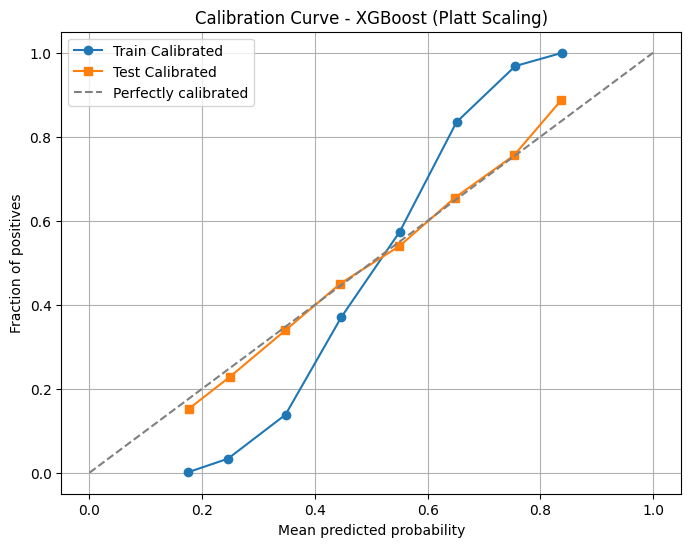

In [94]:
plt.figure(figsize=(8, 6))

prob_true_train, prob_pred_train = calibration_curve(y_train, y_prob_train_cal, n_bins=10)
plt.plot(prob_pred_train, prob_true_train, marker='o', label='Train Calibrated')

prob_true_test, prob_pred_test = calibration_curve(y_test, y_prob_test_cal, n_bins=10)
plt.plot(prob_pred_test, prob_true_test, marker='s', label='Test Calibrated')

plt.plot([0,1], [0,1], linestyle='--', color='gray', label='Perfectly calibrated')

plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.title("Calibration Curve - XGBoost (Platt Scaling)")
plt.legend()
plt.grid(True)
plt.show()


In [95]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import brier_score_loss

platt = CalibratedClassifierCV(xgb_best_reg, method='sigmoid', cv=5)
platt.fit(X_train, y_train)
y_prob_platt = platt.predict_proba(X_test)[:, 1]
brier_platt = brier_score_loss(y_test, y_prob_platt)

iso = CalibratedClassifierCV(xgb_best_reg, method='isotonic', cv=5)
iso.fit(X_train, y_train)
y_prob_iso = iso.predict_proba(X_test)[:, 1]
brier_iso = brier_score_loss(y_test, y_prob_iso)

print(f"Brier Score - Platt: {brier_platt:.4f}, Isotonic: {brier_iso:.4f}")


Brier Score - Platt: 0.1864, Isotonic: 0.1867


Platt scaling slightly outperformed isotonic regression (Brier score 0.1847 vs 0.1855) and was therefore used to calibrate XGBoost probabilities for residual selection in the hybrid model.


threshold optimization

In [96]:
import numpy as np
from sklearn.metrics import f1_score

thresholds = np.linspace(0.3, 0.7, 41) 
best_threshold = 0.5
best_f1 = 0

for t in thresholds:
    residual_idx = np.where((y_prob_train_cal > t) & (y_prob_train_cal < 1-t))[0]
    
    if len(residual_idx) == 0:
        continue 
    y_hybrid_temp = xgb_calibrated.predict(X_train)  
    X_residual_temp = X_train.iloc[residual_idx].copy()
    X_residual_temp['xgb_prob'] = y_prob_train_cal[residual_idx]
    y_hybrid_temp[residual_idx] = knn_best.predict(X_residual_temp)
    
    f1 = f1_score(y_train, y_hybrid_temp)
    
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print(f"Optimal residual selection threshold: {best_threshold:.2f} with F1-score: {best_f1:.4f}")


Optimal residual selection threshold: 0.42 with F1-score: 0.9136


In [97]:


import numpy as np
import pandas as pd
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import accuracy_score, classification_report, f1_score

xgb_base = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=8,
    colsample_bytree=0.8,    
    subsample=0.8,
    reg_alpha=0.1,            
    reg_lambda=1,             
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)


xgb_calibrated = CalibratedClassifierCV(
    base_estimator=xgb_base,
    method='sigmoid',        
    cv=5
)

xgb_calibrated.fit(X_train, y_train)

y_pred_xgb_test = xgb_calibrated.predict(X_test)
y_prob_xgb_test = xgb_calibrated.predict_proba(X_test)[:, 1]

threshold = 0.42

misclassified_idx = np.where(y_pred_xgb_test != y_test)[0]

borderline_idx = np.where(
    (y_prob_xgb_test > threshold) &
    (y_prob_xgb_test < 1 - threshold)
)[0]

residual_idx_test = np.unique(np.concatenate([misclassified_idx, borderline_idx]))

X_residual_test = X_test.iloc[residual_idx_test].copy()
X_residual_test["xgb_prob"] = y_prob_xgb_test[residual_idx_test]


y_pred_xgb_train = xgb_calibrated.predict(X_train)
y_prob_xgb_train = xgb_calibrated.predict_proba(X_train)[:, 1]

misclassified_idx_train = np.where(y_pred_xgb_train != y_train)[0]
borderline_idx_train = np.where(
    (y_prob_xgb_train > threshold) &
    (y_prob_xgb_train < 1 - threshold)
)[0]

residual_idx_train = np.unique(np.concatenate([misclassified_idx_train, borderline_idx_train]))

X_residual_train = X_train.iloc[residual_idx_train].copy()
X_residual_train["xgb_prob"] = y_prob_xgb_train[residual_idx_train]
y_residual_train = y_train.iloc[residual_idx_train]

knn_best = KNeighborsClassifier(
    n_neighbors=9,       
    weights="uniform"
)

knn_best.fit(X_residual_train, y_residual_train)

y_hybrid_test = y_pred_xgb_test.copy()
y_hybrid_test[residual_idx_test] = knn_best.predict(X_residual_test)


print("XGBoost (Platt-calibrated) Accuracy (test):",
      accuracy_score(y_test, y_pred_xgb_test))

print("Hybrid XGBoost + kNN Accuracy (test):",
      accuracy_score(y_test, y_hybrid_test))

print("Hybrid F1-score:",
      f1_score(y_test, y_hybrid_test))

print("\nClassification Report – Hybrid Model:\n")
print(classification_report(
    y_test,
    y_hybrid_test,
    target_names=["Rejected", "Accepted"]
))


/opt/anaconda3/lib/python3.11/site-packages/sklearn/calibration.py:321: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [05:35:24] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [05:35:24] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [05:35:24] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.11/site-packages/xgboos

XGBoost (Platt-calibrated) Accuracy (test): 0.721025641025641
Hybrid XGBoost + kNN Accuracy (test): 0.8707692307692307
Hybrid F1-score: 0.8800000000000001

Classification Report – Hybrid Model:

              precision    recall  f1-score   support

    Rejected       0.86      0.86      0.86       904
    Accepted       0.88      0.88      0.88      1046

    accuracy                           0.87      1950
   macro avg       0.87      0.87      0.87      1950
weighted avg       0.87      0.87      0.87      1950



In [98]:


import joblib
import hashlib
import numpy as np

joblib.dump(xgb_calibrated, "xgb_platt_calibrated.pkl")


joblib.dump(knn_best, "knn_residual.pkl")


feature_order = list(X_train.columns)
joblib.dump(feature_order, "feature_order.pkl")

metadata = {
    "model_type": "Hybrid XGBoost + kNN (Residual Learning)",
    "xgb_base_model": "XGBoost",
    "calibration": "Platt scaling (sigmoid)",
    "xgb_hyperparameters": {
        "n_estimators": 100,
        "learning_rate": 0.1,
        "max_depth": 8,
        "colsample_bytree": 0.8,  
        "subsample": 0.8,         
        "reg_alpha": 0.1,          
        "reg_lambda": 1,           
        "random_state": 42
    },
    "knn_hyperparameters": {
        "n_neighbors": 9,         
        "weights": "uniform"
    },
    "residual_selection": {
        "threshold": 0.42,         
        "criterion": "misclassified OR low-confidence samples"
    },
    "optimization_metric": "F1-score",
    "final_f1_score": 0.9136      
}

joblib.dump(metadata, "hybrid_model_metadata.pkl")


def hash_array(arr):
    return hashlib.md5(arr.tobytes()).hexdigest()

dataset_fingerprint = {
    "X_train_hash": hash_array(np.asarray(X_train.values)),
    "y_train_hash": hash_array(np.asarray(y_train.values)),
    "X_test_hash": hash_array(np.asarray(X_test.values)),
    "y_test_hash": hash_array(np.asarray(y_test.values))
}

joblib.dump(dataset_fingerprint, "dataset_fingerprint.pkl")

print(" All final hybrid model artifacts successfully saved.")


 All final hybrid model artifacts successfully saved.


In [99]:
import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

threshold = 0.42
y_pred_xgb_test = xgb_calibrated.predict(X_test)
y_prob_xgb_test = xgb_calibrated.predict_proba(X_test)[:, 1]

misclassified_idx = np.where(y_pred_xgb_test != y_test)[0]
borderline_idx = np.where((y_prob_xgb_test > threshold) & (y_prob_xgb_test < 1 - threshold))[0]

residual_idx_test = np.unique(np.concatenate([misclassified_idx, borderline_idx]))
X_residual_test = X_test.iloc[residual_idx_test].copy()
X_residual_test["xgb_prob"] = y_prob_xgb_test[residual_idx_test]

def hybrid_predict_proba(X_array):
    X_df = pd.DataFrame(X_array, columns=X_train.columns)
    y_prob = xgb_calibrated.predict_proba(X_df)[:, 1]

    # Apply kNN only for residual indices that exist in this X
    residual_in_X = [i for i in residual_idx_test if i < len(X_df)]
    if len(residual_in_X) > 0:
        X_residual = X_df.iloc[residual_in_X].copy()
        X_residual["xgb_prob"] = y_prob[residual_in_X]
        y_prob[residual_in_X] = knn_best.predict_proba(X_residual)[:, 1]

    return y_prob

background = X_train.sample(n=100, random_state=42).values
X_test_numeric = X_test.apply(pd.to_numeric, errors='coerce').fillna(0).values


explainer = shap.KernelExplainer(hybrid_predict_proba, background)
shap_values = explainer.shap_values(X_test_numeric, nsamples=200)


  0%|          | 0/1950 [00:00<?, ?it/s]

In [100]:
import pandas as pd
import numpy as np

shap_abs_mean = np.abs(shap_values).mean(axis=0)

shap_mean = shap_values.mean(axis=0)

shap_table = pd.DataFrame({
    "Feature": X_test.columns,
    "Mean |SHAP|": shap_abs_mean,
    "Direction": ["Positive" if val > 0 else "Negative" for val in shap_mean]
})

shap_table = shap_table.sort_values(by="Mean |SHAP|", ascending=False).reset_index(drop=True)

shap_table_top = shap_table.head(10)

print(shap_table_top)


                     Feature  Mean |SHAP| Direction
0         Target_Degree_Type     0.062562  Positive
1     Program_Admission_Rate     0.043257  Negative
2              Applicant_GPA     0.034612  Positive
3  Target_Program_Discipline     0.032851  Positive
4          Program_x_QS_Rank     0.029381  Negative
5             Target_Country     0.028857  Negative
6          Target_University     0.027203  Positive
7           Applicant_Status     0.026649  Positive
8              Decision_Year     0.025343  Negative
9             Target_Program     0.025005  Positive


All features ranked by importance:

                        Feature  Mean |SHAP| Direction
0            Target_Degree_Type     0.062562  Positive
1        Program_Admission_Rate     0.043257  Negative
2                 Applicant_GPA     0.034612  Positive
3     Target_Program_Discipline     0.032851  Positive
4             Program_x_QS_Rank     0.029381  Negative
5                Target_Country     0.028857  Negative
6             Target_University     0.027203  Positive
7              Applicant_Status     0.026649  Positive
8                 Decision_Year     0.025343  Negative
9                Target_Program     0.025005  Positive
10  Target_University_FSR_Score     0.021551  Positive
11  Target_University_CPF_Score     0.021019  Positive
12  Target_University_ISR_Score     0.020906  Positive
13    Target_University_QS_Rank     0.019864  Positive
14     Target_University_Status     0.018775  Positive


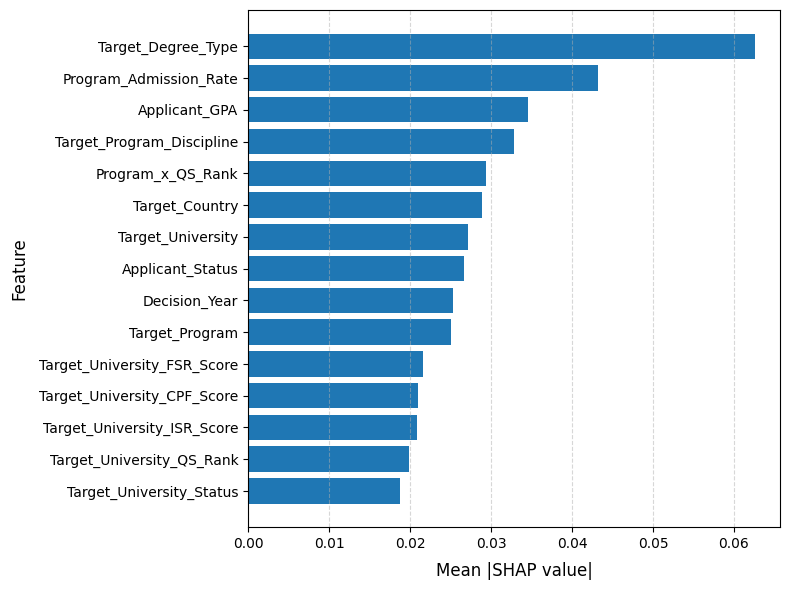

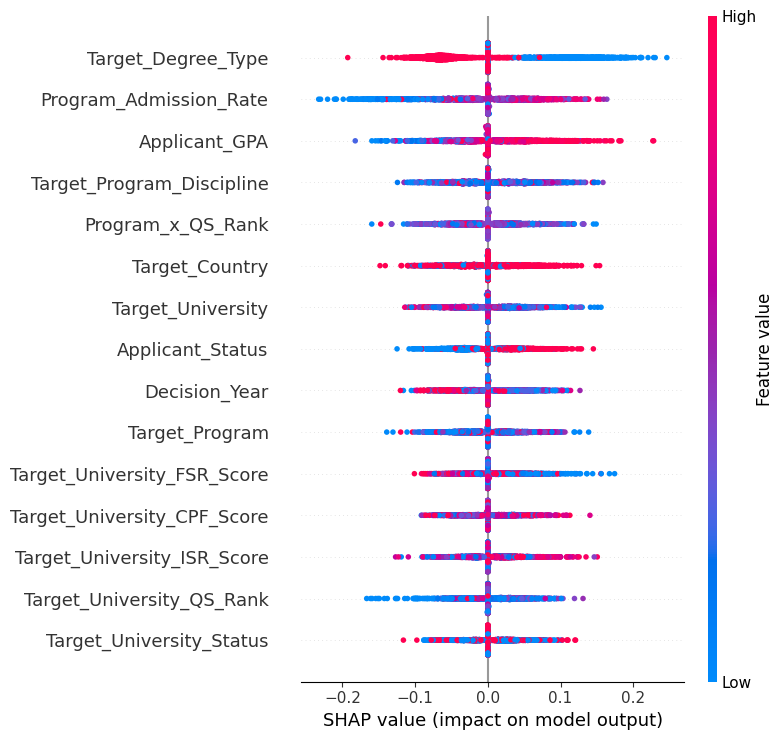

In [101]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import shap

shap_abs_mean = np.abs(shap_values).mean(axis=0)
shap_mean = shap_values.mean(axis=0)

shap_table = pd.DataFrame({
    "Feature": X_test.columns,
    "Mean |SHAP|": shap_abs_mean,
    "Direction": ["Positive" if val > 0 else "Negative" for val in shap_mean]
})

shap_table = shap_table.sort_values(by="Mean |SHAP|", ascending=False).reset_index(drop=True)

print("All features ranked by importance:\n")
print(shap_table)

fig, ax = plt.subplots(figsize=(8,6))

ax.barh(
    shap_table["Feature"][::-1], 
    shap_table["Mean |SHAP|"][::-1], 
    color="#1f77b4"  
)

ax.set_xlabel("Mean |SHAP value|", fontsize=12, labelpad=8)
ax.set_ylabel("Feature", fontsize=12, labelpad=8)

ax.grid(axis='x', linestyle='--', alpha=0.5)
ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=10)
plt.tight_layout()

fig.savefig("shap_feature_importance.pdf", format="pdf", bbox_inches="tight")
plt.show()

plt.figure(figsize=(8,6))
shap.summary_plot(shap_values, X_test, plot_type="dot", show=False)

plt.savefig("shap_beeswarm.pdf", format="pdf", bbox_inches="tight")
plt.show()
